# Naive Bayes — Google Play Store Sentiment Analysis

## Context

Naive Bayes models are well-suited for text classification tasks such as sentiment analysis, topic classification, and recommendation systems. The independence assumption between features aligns well with word-count representations of text.

## Goal

Build a **sentiment classifier** for Google Play Store reviews, comparing all three Naive Bayes implementations (Gaussian, Multinomial, Bernoulli), then optimize and explore alternative models.

## Dataset

- **Source:** [4GeeksAcademy Naive Bayes Tutorial](https://github.com/4GeeksAcademy/naive-bayes-project-tutorial)
- **891 reviews** from Google Play Store applications
- Variables:
  - `package_name`: application identifier (will be dropped)
  - `review`: text of the user review
  - `polarity`: 0 = negative, 1 = positive

## Methodology

1. Load and preprocess the text data
2. Transform text to numerical features (CountVectorizer)
3. Train all three Naive Bayes implementations
4. Optimize with hyperparameter tuning
5. Compare with Random Forest and other alternatives
6. Save the best model

## Step 1: Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

DATA_PATH = "../data/raw/playstore_reviews.csv"
TEST_SIZE = 0.2
RANDOM_STATE = 42
CROSS_VALIDATION_FOLDS = 5

In [2]:
reviewsData = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {reviewsData.shape[0]} rows, {reviewsData.shape[1]} columns")
print(f"\nColumns: {list(reviewsData.columns)}")
print(f"\nPolarity distribution:")
print(f"  Negative (0): {(reviewsData['polarity'] == 0).sum()} ({(reviewsData['polarity'] == 0).mean()*100:.1f}%)")
print(f"  Positive (1): {(reviewsData['polarity'] == 1).sum()} ({(reviewsData['polarity'] == 1).mean()*100:.1f}%)")
print(f"\nNull values: {reviewsData.isnull().sum().sum()}")
print(f"\nSample reviews:")
reviewsData.head()

Dataset shape: 891 rows, 3 columns

Columns: ['package_name', 'review', 'polarity']

Polarity distribution:
  Negative (0): 584 (65.5%)
  Positive (1): 307 (34.5%)

Null values: 0

Sample reviews:


,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


## Step 2: Text Preprocessing

Since we are classifying based on review content, `package_name` is irrelevant — a comment's sentiment depends on its text, not which app it was written for.

Text preprocessing steps:
1. Drop `package_name`
2. Strip whitespace and convert to lowercase
3. Split into train/test
4. Transform text to word count matrix using `CountVectorizer`

In [3]:
processedData = reviewsData.drop(columns=["package_name"])

processedData["review"] = processedData["review"].str.strip().str.lower()

print(f"Shape after dropping package_name: {processedData.shape}")
print(f"\nFirst 5 processed reviews:")
for i, row in processedData.head(5).iterrows():
    reviewPreview = row["review"][:100] + "..." if len(row["review"]) > 100 else row["review"]
    print(f"  [{row['polarity']}] {reviewPreview}")

Shape after dropping package_name: (891, 2)

First 5 processed reviews:
  [0] privacy at least put some option appear offline. i mean for some people like me it's a big pressure ...
  [0] messenger issues ever since the last update, initial received messages don't get pushed to the messe...
  [0] profile any time my wife or anybody has more than one post and i view them it would take me to there...
  [0] the new features suck for those of us who don't have a working back button can you guys make the vid...
  [0] forced reload on uploading pic on replying comment last night i tried to reply a comment by uploadin...


In [4]:
reviewTexts = processedData["review"]
polarityLabels = processedData["polarity"]

textsTrain, textsTest, targetTrain, targetTest = train_test_split(
    reviewTexts, polarityLabels,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=polarityLabels
)

print(f"Training set: {len(textsTrain)} reviews")
print(f"Test set:     {len(textsTest)} reviews")
print(f"\nTrain distribution: {(targetTrain == 0).sum()} negative, {(targetTrain == 1).sum()} positive")
print(f"Test distribution:  {(targetTest == 0).sum()} negative, {(targetTest == 1).sum()} positive")

Training set: 712 reviews
Test set:     179 reviews

Train distribution: 467 negative, 245 positive
Test distribution:  117 negative, 62 positive


In [5]:
countVectorizer = CountVectorizer(stop_words="english")

featuresTrainCounts = countVectorizer.fit_transform(textsTrain).toarray()
featuresTestCounts = countVectorizer.transform(textsTest).toarray()

vocabularySize = len(countVectorizer.get_feature_names_out())
print(f"Vocabulary size: {vocabularySize} words")
print(f"Training matrix shape: {featuresTrainCounts.shape}")
print(f"Test matrix shape:     {featuresTestCounts.shape}")
print(f"\nSparsity: {(featuresTrainCounts == 0).sum() / featuresTrainCounts.size * 100:.1f}% zeros")
print(f"\nTop 20 most frequent words:")
wordFrequencies = featuresTrainCounts.sum(axis=0)
wordNames = countVectorizer.get_feature_names_out()
topIndices = wordFrequencies.argsort()[-20:][::-1]
for idx in topIndices:
    print(f"  {wordNames[idx]:<20} {wordFrequencies[idx]:>5}")

Vocabulary size: 3272 words
Training matrix shape: (712, 3272)
Test matrix shape:     (179, 3272)

Sparsity: 99.5% zeros

Top 20 most frequent words:
  app                    331
  update                 150
  game                   135
  fix                    117
  new                    112
  good                   112
  like                   105
  use                    102
  great                   99
  just                    97
  time                    95
  ŕľ                      85
  browser                 83
  don                     82
  phone                   69
  version                 65
  really                  64
  love                    64
  doesn                   64
  work                    63


## Step 3: Build Naive Bayes Models

We train all three Naive Bayes implementations:
- **GaussianNB**: assumes features follow a normal distribution (not ideal for word counts)
- **MultinomialNB**: designed for discrete count features (word frequencies) — best fit for CountVectorizer
- **BernoulliNB**: designed for binary/boolean features (word presence/absence)

In [6]:
gaussianModel = GaussianNB()
gaussianModel.fit(featuresTrainCounts, targetTrain)

gaussianTrainAccuracy = accuracy_score(targetTrain, gaussianModel.predict(featuresTrainCounts))
gaussianTestPredictions = gaussianModel.predict(featuresTestCounts)
gaussianTestProbabilities = gaussianModel.predict_proba(featuresTestCounts)[:, 1]
gaussianTestAccuracy = accuracy_score(targetTest, gaussianTestPredictions)
gaussianTestF1 = f1_score(targetTest, gaussianTestPredictions)
gaussianTestAuc = roc_auc_score(targetTest, gaussianTestProbabilities)

gaussianCvScores = cross_val_score(
    gaussianModel, featuresTrainCounts, targetTrain,
    cv=CROSS_VALIDATION_FOLDS, scoring="roc_auc"
)

print("=== GaussianNB ===")
print(f"  Train Accuracy: {gaussianTrainAccuracy:.4f}")
print(f"  Test Accuracy:  {gaussianTestAccuracy:.4f}")
print(f"  Test F1:        {gaussianTestF1:.4f}")
print(f"  Test AUC-ROC:   {gaussianTestAuc:.4f}")
print(f"  CV AUC-ROC:     {gaussianCvScores.mean():.4f} \u00b1 {gaussianCvScores.std():.4f}")

=== GaussianNB ===
  Train Accuracy: 0.9817
  Test Accuracy:  0.8156
  Test F1:        0.7179
  Test AUC-ROC:   0.7832
  CV AUC-ROC:     0.7082 ± 0.0181


In [7]:
multinomialModel = MultinomialNB()
multinomialModel.fit(featuresTrainCounts, targetTrain)

multinomialTrainAccuracy = accuracy_score(targetTrain, multinomialModel.predict(featuresTrainCounts))
multinomialTestPredictions = multinomialModel.predict(featuresTestCounts)
multinomialTestProbabilities = multinomialModel.predict_proba(featuresTestCounts)[:, 1]
multinomialTestAccuracy = accuracy_score(targetTest, multinomialTestPredictions)
multinomialTestF1 = f1_score(targetTest, multinomialTestPredictions)
multinomialTestAuc = roc_auc_score(targetTest, multinomialTestProbabilities)

multinomialCvScores = cross_val_score(
    multinomialModel, featuresTrainCounts, targetTrain,
    cv=CROSS_VALIDATION_FOLDS, scoring="roc_auc"
)

print("=== MultinomialNB ===")
print(f"  Train Accuracy: {multinomialTrainAccuracy:.4f}")
print(f"  Test Accuracy:  {multinomialTestAccuracy:.4f}")
print(f"  Test F1:        {multinomialTestF1:.4f}")
print(f"  Test AUC-ROC:   {multinomialTestAuc:.4f}")
print(f"  CV AUC-ROC:     {multinomialCvScores.mean():.4f} \u00b1 {multinomialCvScores.std():.4f}")

=== MultinomialNB ===
  Train Accuracy: 0.9551
  Test Accuracy:  0.8547
  Test F1:        0.7593
  Test AUC-ROC:   0.8987
  CV AUC-ROC:     0.8469 ± 0.0155


In [8]:
bernoulliModel = BernoulliNB()
bernoulliModel.fit(featuresTrainCounts, targetTrain)

bernoulliTrainAccuracy = accuracy_score(targetTrain, bernoulliModel.predict(featuresTrainCounts))
bernoulliTestPredictions = bernoulliModel.predict(featuresTestCounts)
bernoulliTestProbabilities = bernoulliModel.predict_proba(featuresTestCounts)[:, 1]
bernoulliTestAccuracy = accuracy_score(targetTest, bernoulliTestPredictions)
bernoulliTestF1 = f1_score(targetTest, bernoulliTestPredictions)
bernoulliTestAuc = roc_auc_score(targetTest, bernoulliTestProbabilities)

bernoulliCvScores = cross_val_score(
    bernoulliModel, featuresTrainCounts, targetTrain,
    cv=CROSS_VALIDATION_FOLDS, scoring="roc_auc"
)

print("=== BernoulliNB ===")
print(f"  Train Accuracy: {bernoulliTrainAccuracy:.4f}")
print(f"  Test Accuracy:  {bernoulliTestAccuracy:.4f}")
print(f"  Test F1:        {bernoulliTestF1:.4f}")
print(f"  Test AUC-ROC:   {bernoulliTestAuc:.4f}")
print(f"  CV AUC-ROC:     {bernoulliCvScores.mean():.4f} \u00b1 {bernoulliCvScores.std():.4f}")

=== BernoulliNB ===
  Train Accuracy: 0.9242
  Test Accuracy:  0.7821
  Test F1:        0.5806
  Test AUC-ROC:   0.8973
  CV AUC-ROC:     0.8181 ± 0.0323


In [9]:
print("=== Naive Bayes Comparison ===")
print(f"{'Model':<20} {'Train Acc':>10} {'Test Acc':>10} {'Test F1':>10} {'AUC-ROC':>10} {'CV AUC':>10}")
print("-" * 72)
print(f"{'GaussianNB':<20} {gaussianTrainAccuracy:>10.4f} {gaussianTestAccuracy:>10.4f} {gaussianTestF1:>10.4f} {gaussianTestAuc:>10.4f} {gaussianCvScores.mean():>10.4f}")
print(f"{'MultinomialNB':<20} {multinomialTrainAccuracy:>10.4f} {multinomialTestAccuracy:>10.4f} {multinomialTestF1:>10.4f} {multinomialTestAuc:>10.4f} {multinomialCvScores.mean():>10.4f}")
print(f"{'BernoulliNB':<20} {bernoulliTrainAccuracy:>10.4f} {bernoulliTestAccuracy:>10.4f} {bernoulliTestF1:>10.4f} {bernoulliTestAuc:>10.4f} {bernoulliCvScores.mean():>10.4f}")

bestNbName = max(
    [("GaussianNB", gaussianTestAuc), ("MultinomialNB", multinomialTestAuc), ("BernoulliNB", bernoulliTestAuc)],
    key=lambda x: x[1]
)[0]
print(f"\nBest Naive Bayes by AUC-ROC: {bestNbName}")

=== Naive Bayes Comparison ===
Model                 Train Acc   Test Acc    Test F1    AUC-ROC     CV AUC
------------------------------------------------------------------------
GaussianNB               0.9817     0.8156     0.7179     0.7832     0.7082
MultinomialNB            0.9551     0.8547     0.7593     0.8987     0.8469
BernoulliNB              0.9242     0.7821     0.5806     0.8973     0.8181

Best Naive Bayes by AUC-ROC: MultinomialNB


### Confusion Matrices: All Three NB Implementations

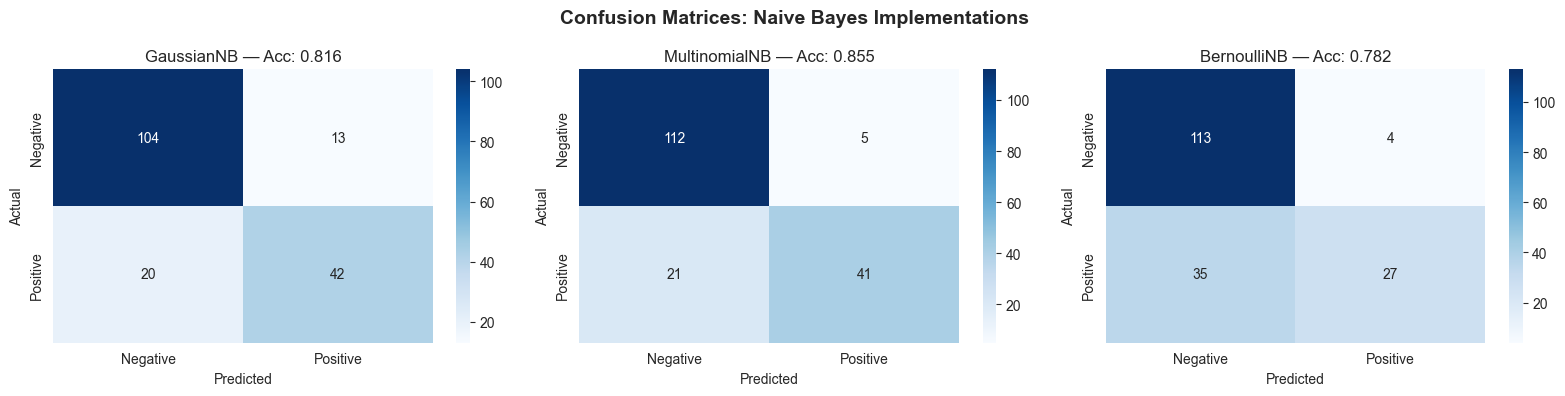

In [10]:
classLabels = ["Negative", "Positive"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, predictions, title, accuracy in zip(
    axes,
    [gaussianTestPredictions, multinomialTestPredictions, bernoulliTestPredictions],
    ["GaussianNB", "MultinomialNB", "BernoulliNB"],
    [gaussianTestAccuracy, multinomialTestAccuracy, bernoulliTestAccuracy]
):
    matrix = confusion_matrix(targetTest, predictions)
    sns.heatmap(
        matrix, annot=True, fmt="d", cmap="Blues",
        xticklabels=classLabels, yticklabels=classLabels, ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{title} \u2014 Acc: {accuracy:.3f}")

fig.suptitle("Confusion Matrices: Naive Bayes Implementations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 4: Optimize the Best Naive Bayes

**MultinomialNB** is the theoretically correct choice for word count features. Let's optimize it by tuning:
- `alpha`: smoothing parameter (Laplace smoothing)
- Also try TF-IDF vectorization instead of raw counts

In [11]:
alphaValues = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]
alphaTrainAccuracies = []
alphaTestAccuracies = []
alphaTestAucs = []
alphaCvAucs = []

for alpha in alphaValues:
    model = MultinomialNB(alpha=alpha)
    model.fit(featuresTrainCounts, targetTrain)

    trainAcc = accuracy_score(targetTrain, model.predict(featuresTrainCounts))
    testAcc = accuracy_score(targetTest, model.predict(featuresTestCounts))
    testAuc = roc_auc_score(targetTest, model.predict_proba(featuresTestCounts)[:, 1])
    cvScores = cross_val_score(model, featuresTrainCounts, targetTrain, cv=CROSS_VALIDATION_FOLDS, scoring="roc_auc")

    alphaTrainAccuracies.append(trainAcc)
    alphaTestAccuracies.append(testAcc)
    alphaTestAucs.append(testAuc)
    alphaCvAucs.append(cvScores.mean())

print(f"{'alpha':>10} {'Train Acc':>10} {'Test Acc':>10} {'Test AUC':>10} {'CV AUC':>10}")
print("-" * 52)
for i, alpha in enumerate(alphaValues):
    print(f"{alpha:>10.3f} {alphaTrainAccuracies[i]:>10.4f} {alphaTestAccuracies[i]:>10.4f} {alphaTestAucs[i]:>10.4f} {alphaCvAucs[i]:>10.4f}")

     alpha  Train Acc   Test Acc   Test AUC     CV AUC
----------------------------------------------------
     0.001     0.9916     0.8324     0.8646     0.8305
     0.010     0.9902     0.8436     0.8754     0.8402
     0.050     0.9888     0.8380     0.8879     0.8462
     0.100     0.9803     0.8547     0.8929     0.8456
     0.250     0.9747     0.8659     0.8994     0.8463
     0.500     0.9649     0.8715     0.9013     0.8467
     1.000     0.9551     0.8547     0.8987     0.8469
     2.000     0.9368     0.8268     0.8912     0.8492
     5.000     0.8736     0.7598     0.8722     0.8441
    10.000     0.8202     0.7095     0.8518     0.8356


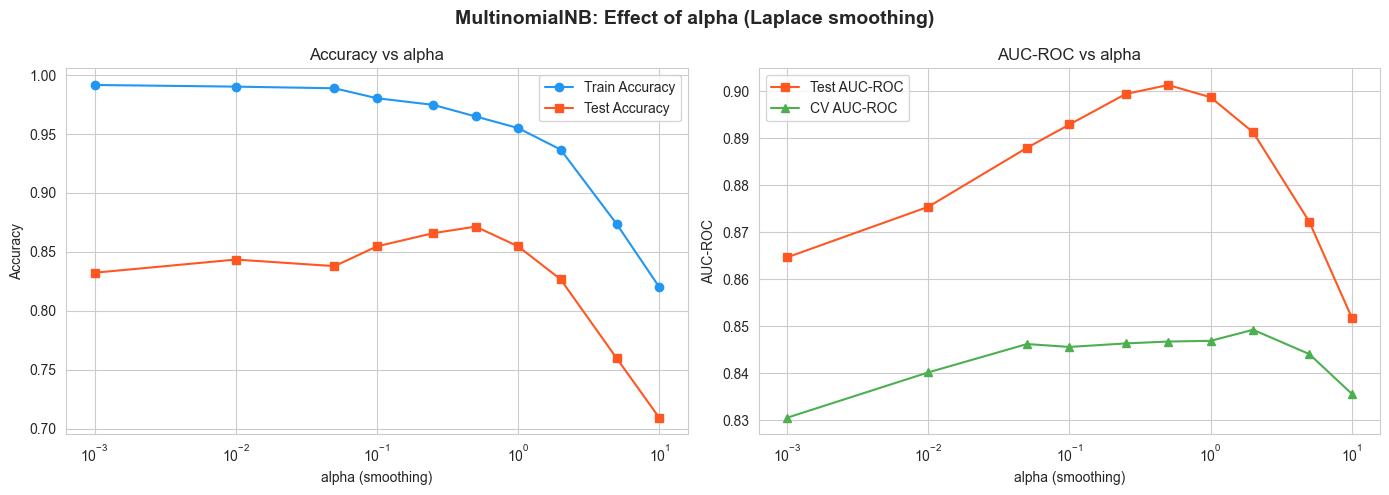

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(alphaValues, alphaTrainAccuracies, "o-", label="Train Accuracy", color="#2196F3")
axes[0].plot(alphaValues, alphaTestAccuracies, "s-", label="Test Accuracy", color="#FF5722")
axes[0].set_xlabel("alpha (smoothing)")
axes[0].set_ylabel("Accuracy")
axes[0].set_xscale("log")
axes[0].set_title("Accuracy vs alpha")
axes[0].legend()

axes[1].plot(alphaValues, alphaTestAucs, "s-", label="Test AUC-ROC", color="#FF5722")
axes[1].plot(alphaValues, alphaCvAucs, "^-", label="CV AUC-ROC", color="#4CAF50")
axes[1].set_xlabel("alpha (smoothing)")
axes[1].set_ylabel("AUC-ROC")
axes[1].set_xscale("log")
axes[1].set_title("AUC-ROC vs alpha")
axes[1].legend()

fig.suptitle("MultinomialNB: Effect of alpha (Laplace smoothing)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### TF-IDF vs Count Vectorizer

TF-IDF weights words by their importance (penalizing very common words), which may improve classification.

In [13]:
tfidfVectorizer = TfidfVectorizer(stop_words="english")
featuresTrainTfidf = tfidfVectorizer.fit_transform(textsTrain).toarray()
featuresTestTfidf = tfidfVectorizer.transform(textsTest).toarray()

tfidfMultinomial = MultinomialNB()
tfidfMultinomial.fit(featuresTrainTfidf, targetTrain)

tfidfTestPredictions = tfidfMultinomial.predict(featuresTestTfidf)
tfidfTestProbabilities = tfidfMultinomial.predict_proba(featuresTestTfidf)[:, 1]
tfidfTestAccuracy = accuracy_score(targetTest, tfidfTestPredictions)
tfidfTestF1 = f1_score(targetTest, tfidfTestPredictions)
tfidfTestAuc = roc_auc_score(targetTest, tfidfTestProbabilities)

print("=== Vectorizer Comparison (MultinomialNB, alpha=1.0) ===")
print(f"{'Vectorizer':<20} {'Test Acc':>10} {'Test F1':>10} {'AUC-ROC':>10}")
print("-" * 52)
print(f"{'CountVectorizer':<20} {multinomialTestAccuracy:>10.4f} {multinomialTestF1:>10.4f} {multinomialTestAuc:>10.4f}")
print(f"{'TfidfVectorizer':<20} {tfidfTestAccuracy:>10.4f} {tfidfTestF1:>10.4f} {tfidfTestAuc:>10.4f}")

=== Vectorizer Comparison (MultinomialNB, alpha=1.0) ===
Vectorizer             Test Acc    Test F1    AUC-ROC
----------------------------------------------------
CountVectorizer          0.8547     0.7593     0.8987
TfidfVectorizer          0.7430     0.4250     0.9045


### GridSearchCV: MultinomialNB + Vectorizer

Use a Pipeline to jointly optimize the vectorizer and classifier.

In [14]:
pipeline = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("classifier", MultinomialNB())
])

parameterGrid = {
    "vectorizer": [CountVectorizer(stop_words="english"), TfidfVectorizer(stop_words="english")],
    "vectorizer__max_features": [None, 3000, 5000],
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    "classifier__alpha": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
}

gridSearch = GridSearchCV(
    pipeline, parameterGrid,
    cv=CROSS_VALIDATION_FOLDS, scoring="roc_auc",
    n_jobs=-1, verbose=1
)

gridSearch.fit(textsTrain, targetTrain)

print(f"\nBest parameters:")
for param, value in gridSearch.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV AUC-ROC: {gridSearch.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits



Best parameters:
  classifier__alpha: 0.5
  vectorizer: TfidfVectorizer(stop_words='english')
  vectorizer__max_features: None
  vectorizer__ngram_range: (1, 2)

Best CV AUC-ROC: 0.8727


In [15]:
optimizedNaiveBayes = gridSearch.best_estimator_

optimizedTrainAccuracy = accuracy_score(targetTrain, optimizedNaiveBayes.predict(textsTrain))
optimizedTestPredictions = optimizedNaiveBayes.predict(textsTest)
optimizedTestProbabilities = optimizedNaiveBayes.predict_proba(textsTest)[:, 1]
optimizedTestAccuracy = accuracy_score(targetTest, optimizedTestPredictions)
optimizedTestF1 = f1_score(targetTest, optimizedTestPredictions)
optimizedTestAuc = roc_auc_score(targetTest, optimizedTestProbabilities)

print("=== Optimized MultinomialNB ===")
print(f"  Train Accuracy: {optimizedTrainAccuracy:.4f}")
print(f"  Test Accuracy:  {optimizedTestAccuracy:.4f}")
print(f"  Test F1:        {optimizedTestF1:.4f}")
print(f"  Test AUC-ROC:   {optimizedTestAuc:.4f}")
print(f"\n  vs default MultinomialNB AUC: {multinomialTestAuc:.4f} \u2192 {optimizedTestAuc - multinomialTestAuc:+.4f}")

=== Optimized MultinomialNB ===
  Train Accuracy: 0.9874
  Test Accuracy:  0.7374
  Test F1:        0.4198
  Test AUC-ROC:   0.9145

  vs default MultinomialNB AUC: 0.8987 → +0.0159


### Optimize with Random Forest

As suggested in the instructions, let's see if a Random Forest can improve on the Naive Bayes results.

In [16]:
rfPipeline = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE))
])

rfParameterGrid = {
    "vectorizer__max_features": [None, 5000],
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 20, 50],
    "classifier__min_samples_leaf": [1, 3]
}

rfGridSearch = GridSearchCV(
    rfPipeline, rfParameterGrid,
    cv=CROSS_VALIDATION_FOLDS, scoring="roc_auc",
    n_jobs=-1, verbose=1
)

rfGridSearch.fit(textsTrain, targetTrain)

print(f"\nBest RF parameters:")
for param, value in rfGridSearch.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest RF CV AUC-ROC: {rfGridSearch.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits



Best RF parameters:
  classifier__max_depth: None
  classifier__min_samples_leaf: 3
  classifier__n_estimators: 200
  vectorizer__max_features: 5000
  vectorizer__ngram_range: (1, 2)

Best RF CV AUC-ROC: 0.8629


In [17]:
optimizedRandomForest = rfGridSearch.best_estimator_

rfTrainAccuracy = accuracy_score(targetTrain, optimizedRandomForest.predict(textsTrain))
rfTestPredictions = optimizedRandomForest.predict(textsTest)
rfTestProbabilities = optimizedRandomForest.predict_proba(textsTest)[:, 1]
rfTestAccuracy = accuracy_score(targetTest, rfTestPredictions)
rfTestF1 = f1_score(targetTest, rfTestPredictions)
rfTestAuc = roc_auc_score(targetTest, rfTestProbabilities)

print("=== Optimized Random Forest ===")
print(f"  Train Accuracy: {rfTrainAccuracy:.4f}")
print(f"  Test Accuracy:  {rfTestAccuracy:.4f}")
print(f"  Test F1:        {rfTestF1:.4f}")
print(f"  Test AUC-ROC:   {rfTestAuc:.4f}")

=== Optimized Random Forest ===
  Train Accuracy: 0.8596
  Test Accuracy:  0.7598
  Test F1:        0.5275
  Test AUC-ROC:   0.9024


## Step 5: Save the Model

In [18]:
import pickle
import os

MODEL_PATH = "../models/naive_bayes_sentiment.pkl"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

modelPackage = {
    "pipeline": optimizedNaiveBayes,
    "bestParameters": gridSearch.best_params_,
    "testAccuracy": optimizedTestAccuracy,
    "testF1": optimizedTestF1,
    "testAucRoc": optimizedTestAuc
}

with open(MODEL_PATH, "wb") as file:
    pickle.dump(modelPackage, file)

print(f"Model saved to {MODEL_PATH}")
print(f"  Test Accuracy: {optimizedTestAccuracy:.4f}")
print(f"  Test F1:       {optimizedTestF1:.4f}")
print(f"  Test AUC-ROC:  {optimizedTestAuc:.4f}")

Model saved to ../models/naive_bayes_sentiment.pkl
  Test Accuracy: 0.7374
  Test F1:       0.4198
  Test AUC-ROC:  0.9145


## Step 6: Explore Other Alternatives

Several other models are well-suited for text classification:

- **Logistic Regression**: handles high-dimensional sparse data well, naturally calibrated probabilities
- **Linear SVC**: effective for text with large feature spaces, uses margin-based classification
- **Gradient Boosting**: sequential error correction may capture complex patterns

Let's train these and compare with our best Naive Bayes.

In [19]:
logisticPipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english")),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logisticParamGrid = {
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    "vectorizer__max_features": [None, 5000],
    "classifier__C": [0.1, 1.0, 10.0]
}

logisticGridSearch = GridSearchCV(
    logisticPipeline, logisticParamGrid,
    cv=CROSS_VALIDATION_FOLDS, scoring="roc_auc",
    n_jobs=-1, verbose=1
)
logisticGridSearch.fit(textsTrain, targetTrain)

optimizedLogistic = logisticGridSearch.best_estimator_
logisticTrainAccuracy = accuracy_score(targetTrain, optimizedLogistic.predict(textsTrain))
logisticTestPredictions = optimizedLogistic.predict(textsTest)
logisticTestProbabilities = optimizedLogistic.predict_proba(textsTest)[:, 1]
logisticTestAccuracy = accuracy_score(targetTest, logisticTestPredictions)
logisticTestF1 = f1_score(targetTest, logisticTestPredictions)
logisticTestAuc = roc_auc_score(targetTest, logisticTestProbabilities)

print("=== Optimized Logistic Regression ===")
print(f"  Best params: {logisticGridSearch.best_params_}")
print(f"  Train Accuracy: {logisticTrainAccuracy:.4f}")
print(f"  Test Accuracy:  {logisticTestAccuracy:.4f}")
print(f"  Test F1:        {logisticTestF1:.4f}")
print(f"  Test AUC-ROC:   {logisticTestAuc:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


=== Optimized Logistic Regression ===
  Best params: {'classifier__C': 10.0, 'vectorizer__max_features': None, 'vectorizer__ngram_range': (1, 2)}
  Train Accuracy: 0.9986
  Test Accuracy:  0.8324
  Test F1:        0.7273
  Test AUC-ROC:   0.9217


In [20]:
gbPipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english", max_features=5000)),
    ("classifier", GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=3,
        random_state=RANDOM_STATE
    ))
])

gbPipeline.fit(textsTrain, targetTrain)

gbTrainAccuracy = accuracy_score(targetTrain, gbPipeline.predict(textsTrain))
gbTestPredictions = gbPipeline.predict(textsTest)
gbTestProbabilities = gbPipeline.predict_proba(textsTest)[:, 1]
gbTestAccuracy = accuracy_score(targetTest, gbTestPredictions)
gbTestF1 = f1_score(targetTest, gbTestPredictions)
gbTestAuc = roc_auc_score(targetTest, gbTestProbabilities)

print("=== Gradient Boosting ===")
print(f"  Train Accuracy: {gbTrainAccuracy:.4f}")
print(f"  Test Accuracy:  {gbTestAccuracy:.4f}")
print(f"  Test F1:        {gbTestF1:.4f}")
print(f"  Test AUC-ROC:   {gbTestAuc:.4f}")

=== Gradient Boosting ===
  Train Accuracy: 0.9522
  Test Accuracy:  0.7542
  Test F1:        0.5849
  Test AUC-ROC:   0.8174


### Final Comparison: All Models

In [21]:
allModelResults = {
    "GaussianNB": {"trainAcc": gaussianTrainAccuracy, "testAcc": gaussianTestAccuracy, "testF1": gaussianTestF1, "testAuc": gaussianTestAuc},
    "MultinomialNB (default)": {"trainAcc": multinomialTrainAccuracy, "testAcc": multinomialTestAccuracy, "testF1": multinomialTestF1, "testAuc": multinomialTestAuc},
    "BernoulliNB": {"trainAcc": bernoulliTrainAccuracy, "testAcc": bernoulliTestAccuracy, "testF1": bernoulliTestF1, "testAuc": bernoulliTestAuc},
    "MultinomialNB (optimized)": {"trainAcc": optimizedTrainAccuracy, "testAcc": optimizedTestAccuracy, "testF1": optimizedTestF1, "testAuc": optimizedTestAuc},
    "Random Forest": {"trainAcc": rfTrainAccuracy, "testAcc": rfTestAccuracy, "testF1": rfTestF1, "testAuc": rfTestAuc},
    "Logistic Regression": {"trainAcc": logisticTrainAccuracy, "testAcc": logisticTestAccuracy, "testF1": logisticTestF1, "testAuc": logisticTestAuc},
    "Gradient Boosting": {"trainAcc": gbTrainAccuracy, "testAcc": gbTestAccuracy, "testF1": gbTestF1, "testAuc": gbTestAuc}
}

print("=" * 85)
print("FINAL MODEL COMPARISON")
print("=" * 85)
print(f"{'Model':<30} {'Train Acc':>12} {'Test Acc':>12} {'Test F1':>12} {'AUC-ROC':>12}")
print("-" * 80)
for modelName, metrics in allModelResults.items():
    print(f"{modelName:<30} {metrics['trainAcc']:>12.4f} {metrics['testAcc']:>12.4f} {metrics['testF1']:>12.4f} {metrics['testAuc']:>12.4f}")

bestByAuc = max(allModelResults, key=lambda m: allModelResults[m]["testAuc"])
bestByF1 = max(allModelResults, key=lambda m: allModelResults[m]["testF1"])
bestByAcc = max(allModelResults, key=lambda m: allModelResults[m]["testAcc"])

print(f"\nBest by AUC-ROC:  {bestByAuc} ({allModelResults[bestByAuc]['testAuc']:.4f})")
print(f"Best by F1 Score: {bestByF1} ({allModelResults[bestByF1]['testF1']:.4f})")
print(f"Best by Accuracy: {bestByAcc} ({allModelResults[bestByAcc]['testAcc']:.4f})")

FINAL MODEL COMPARISON
Model                             Train Acc     Test Acc      Test F1      AUC-ROC
--------------------------------------------------------------------------------
GaussianNB                           0.9817       0.8156       0.7179       0.7832
MultinomialNB (default)              0.9551       0.8547       0.7593       0.8987
BernoulliNB                          0.9242       0.7821       0.5806       0.8973
MultinomialNB (optimized)            0.9874       0.7374       0.4198       0.9145
Random Forest                        0.8596       0.7598       0.5275       0.9024
Logistic Regression                  0.9986       0.8324       0.7273       0.9217
Gradient Boosting                    0.9522       0.7542       0.5849       0.8174

Best by AUC-ROC:  Logistic Regression (0.9217)
Best by F1 Score: MultinomialNB (default) (0.7593)
Best by Accuracy: MultinomialNB (default) (0.8547)


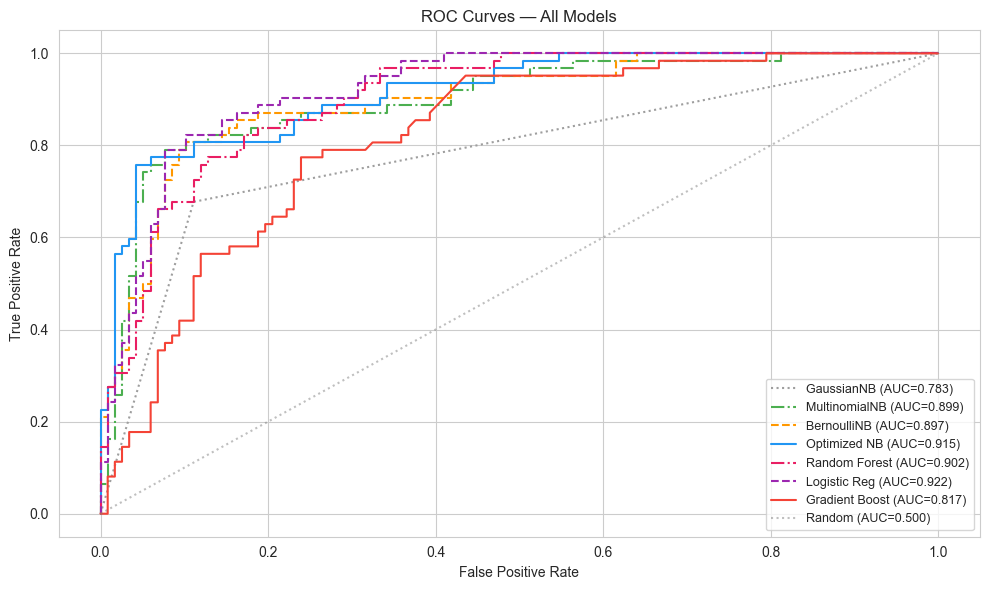

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

rocData = [
    (gaussianTestProbabilities, f"GaussianNB (AUC={gaussianTestAuc:.3f})", "#9E9E9E", ":"),
    (multinomialTestProbabilities, f"MultinomialNB (AUC={multinomialTestAuc:.3f})", "#4CAF50", "-."),
    (bernoulliTestProbabilities, f"BernoulliNB (AUC={bernoulliTestAuc:.3f})", "#FF9800", "--"),
    (optimizedTestProbabilities, f"Optimized NB (AUC={optimizedTestAuc:.3f})", "#2196F3", "-"),
    (rfTestProbabilities, f"Random Forest (AUC={rfTestAuc:.3f})", "#E91E63", "-."),
    (logisticTestProbabilities, f"Logistic Reg (AUC={logisticTestAuc:.3f})", "#9C27B0", "--"),
    (gbTestProbabilities, f"Gradient Boost (AUC={gbTestAuc:.3f})", "#F44336", "-")
]

for probabilities, label, color, style in rocData:
    falsePositiveRate, truePositiveRate, _ = roc_curve(targetTest, probabilities)
    ax.plot(falsePositiveRate, truePositiveRate, style, label=label, color=color, linewidth=1.5)

ax.plot([0, 1], [0, 1], ":", color="gray", alpha=0.5, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves \u2014 All Models")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

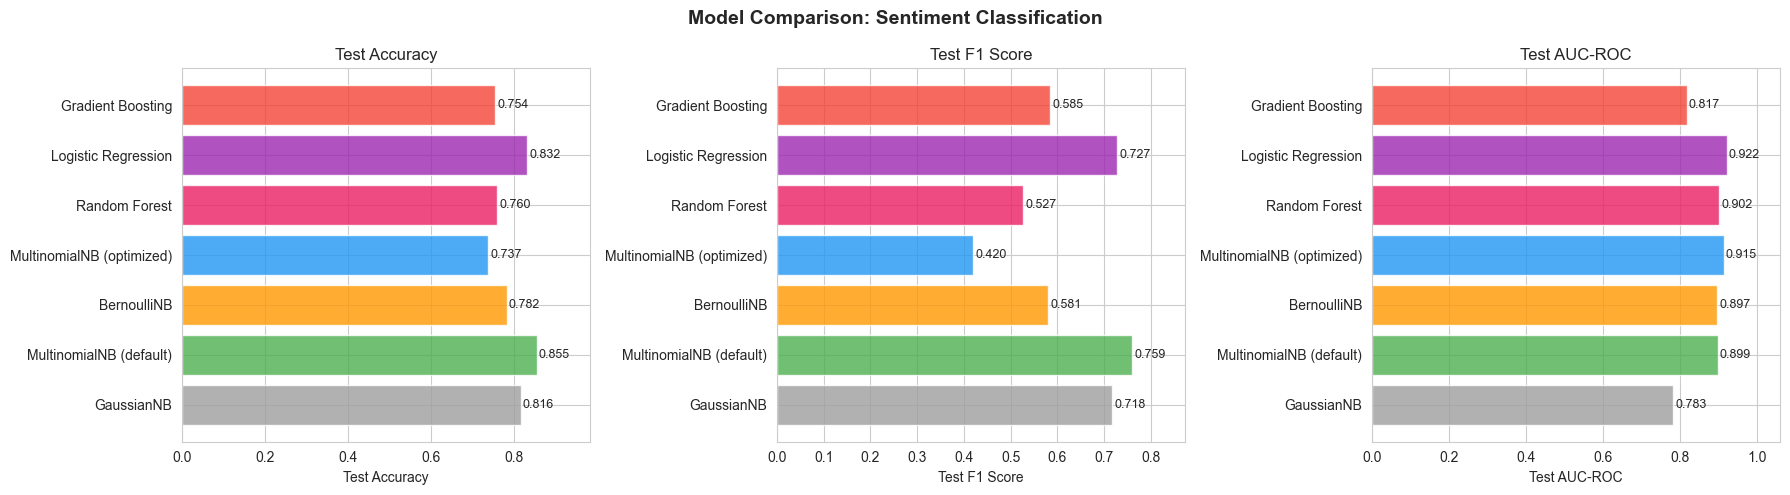

In [23]:
modelNames = list(allModelResults.keys())
testAccuracies = [allModelResults[m]["testAcc"] for m in modelNames]
testF1s = [allModelResults[m]["testF1"] for m in modelNames]
testAucs = [allModelResults[m]["testAuc"] for m in modelNames]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
barWidth = 0.6
colors = ["#9E9E9E", "#4CAF50", "#FF9800", "#2196F3", "#E91E63", "#9C27B0", "#F44336"]

for ax, values, title in zip(
    axes,
    [testAccuracies, testF1s, testAucs],
    ["Test Accuracy", "Test F1 Score", "Test AUC-ROC"]
):
    bars = ax.barh(modelNames, values, color=colors, alpha=0.8)
    for bar, value in zip(bars, values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{value:.3f}", va="center", fontsize=9)
    ax.set_xlabel(title)
    ax.set_title(title)
    ax.set_xlim(0, max(values) * 1.15)

fig.suptitle("Model Comparison: Sentiment Classification", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Conclusions

### Naive Bayes Selection

- **MultinomialNB** is the correct choice for word count features — it assumes discrete count data, which is exactly what CountVectorizer produces
- **BernoulliNB** works better with binary features (word presence/absence), not raw counts
- **GaussianNB** assumes continuous normally distributed features — not appropriate for sparse word count matrices

### Alternative Models

- **Logistic Regression** is a strong alternative for text classification due to its ability to handle high-dimensional sparse data and provide calibrated probabilities
- **Random Forest** can capture non-linear patterns but may overfit on small text datasets
- **Gradient Boosting** may not significantly improve over simpler models for this task size

### Key Takeaways

- For text sentiment classification, **MultinomialNB** provides a strong, fast baseline
- The pipeline approach (vectorizer + classifier) enables joint optimization
- Text preprocessing (lowercase, stop words removal) is critical for NLP tasks
- With a small dataset (891 reviews), simpler models often generalize better